In [4]:
# ============================================================
# PHASE 5 — FEATURE-LEVEL EDA
# NIFTY 50 Binary Next-Day Trend Classification
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load the featured dataset
# ------------------------------------------------------------

input_path = "../data/processed/NIFTY50_FEATURED.csv"
df = pd.read_csv(input_path)

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort chronologically
df = df.sort_values("Date").reset_index(drop=True)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (1191, 17)


In [5]:
# ------------------------------------------------------------
# 2. Dataset overview
# ------------------------------------------------------------

print("\n===== DATASET OVERVIEW =====")

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDate range:")
print("Start:", df["Date"].min())
print("End:", df["Date"].max())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


===== DATASET OVERVIEW =====

Number of rows: 1191
Number of columns: 17

Column names:
['Date', 'Open', 'High', 'Low', 'Close', 'Next_Day_Return', 'Target', 'Daily_Return', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'Momentum_10', 'RSI_14', 'MACD', 'MACD_Signal', 'Volatility_20']

Data types:
Date               datetime64[ns]
Open                      float64
High                      float64
Low                       float64
Close                     float64
Next_Day_Return           float64
Target                      int64
Daily_Return              float64
SMA_5                     float64
SMA_10                    float64
SMA_20                    float64
SMA_50                    float64
Momentum_10               float64
RSI_14                    float64
MACD                      float64
MACD_Signal               float64
Volatility_20             float64
dtype: object

Date range:
Start: 2021-12-01 00:00:00
End: 2026-09-17 00:00:00

Missing values:
Date               0
Open         

In [6]:
# ------------------------------------------------------------
# 3. Target distribution
# ------------------------------------------------------------

print("\n===== TARGET DISTRIBUTION =====")

target_counts = df["Target"].value_counts().sort_index()
target_percent = df["Target"].value_counts(normalize=True).sort_index() * 100

print("\nCounts:")
print(target_counts)

print("\nPercentages:")
print(target_percent.round(2))

print("\nTarget meaning:")
print("0 = DOWN")
print("1 = UP")


===== TARGET DISTRIBUTION =====

Counts:
Target
0    566
1    625
Name: count, dtype: int64

Percentages:
Target
0    47.52
1    52.48
Name: proportion, dtype: float64

Target meaning:
0 = DOWN
1 = UP


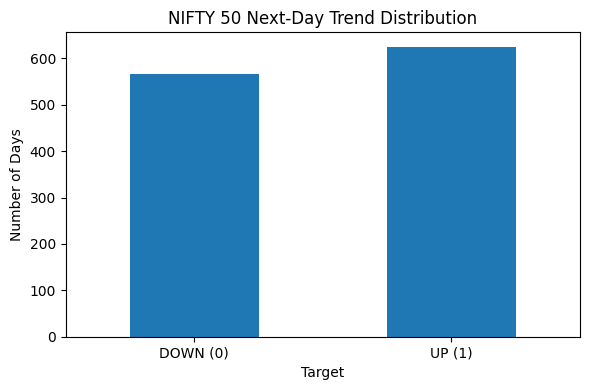

In [7]:
plt.figure(figsize=(6, 4))

target_counts.plot(kind="bar")

plt.title("NIFTY 50 Next-Day Trend Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Days")
plt.xticks([0, 1], ["DOWN (0)", "UP (1)"], rotation=0)

plt.tight_layout()
plt.show()

In [8]:
# ------------------------------------------------------------
# 4. Descriptive statistics
# ------------------------------------------------------------

print("\n===== DESCRIPTIVE STATISTICS =====")

numeric_columns = df.select_dtypes(include=np.number).columns

print(df[numeric_columns].describe().T)


===== DESCRIPTIVE STATISTICS =====
                  count          mean          std           min  \
Open             1191.0  21471.892275  3254.924282  15272.650000   
High             1191.0  21565.931276  3262.781900  15382.500000   
Low              1191.0  21357.380395  3249.255889  15183.400000   
Close            1191.0  21463.697691  3253.718704  15293.500000   
Next_Day_Return  1191.0      0.000296     0.008692     -0.059294   
Target           1191.0      0.524769     0.499596      0.000000   
Daily_Return     1191.0      0.000302     0.008697     -0.059294   
SMA_5            1191.0  21453.338883  3253.840522  15411.270000   
SMA_10           1191.0  21440.656406  3253.541005  15551.090000   
SMA_20           1191.0  21415.297326  3250.301035  15724.762500   
SMA_50           1191.0  21336.622029  3236.033336  16026.548000   
Momentum_10      1191.0     50.799454   563.568611  -2345.450000   
RSI_14           1191.0     53.376419    17.788992      2.022397   
MACD        

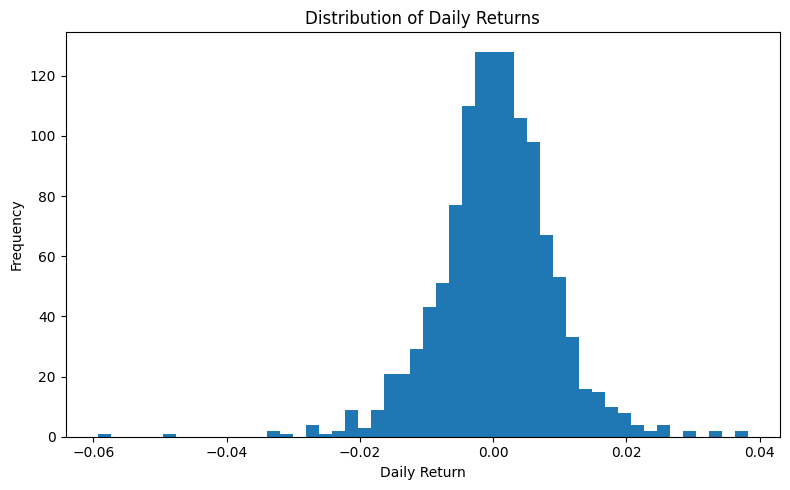

In [9]:
# ------------------------------------------------------------
# 5. Daily Return distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(df["Daily_Return"], bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

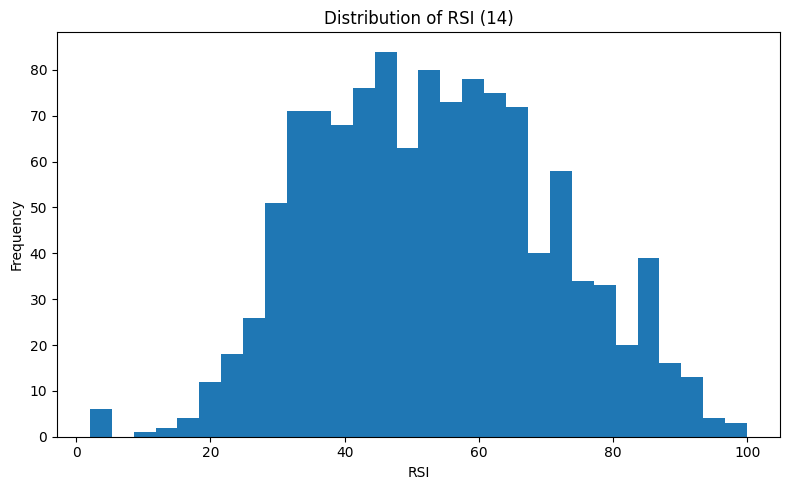

In [10]:
# ------------------------------------------------------------
# 6. RSI distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(df["RSI_14"], bins=30)

plt.title("Distribution of RSI (14)")
plt.xlabel("RSI")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

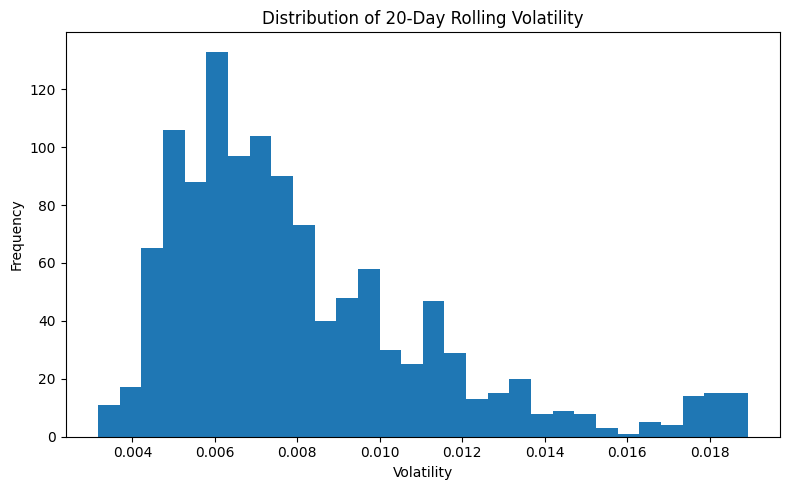

In [11]:
# ------------------------------------------------------------
# 7. Volatility distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(df["Volatility_20"], bins=30)

plt.title("Distribution of 20-Day Rolling Volatility")
plt.xlabel("Volatility")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

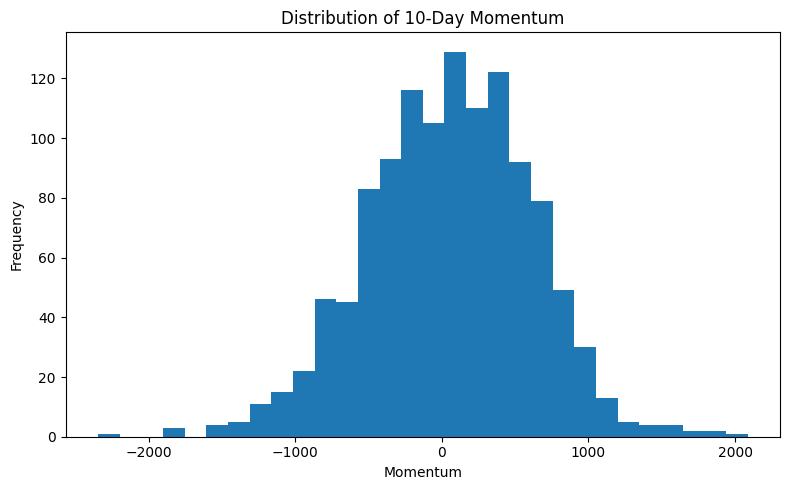

In [12]:
# ------------------------------------------------------------
# 8. Momentum distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(df["Momentum_10"], bins=30)

plt.title("Distribution of 10-Day Momentum")
plt.xlabel("Momentum")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

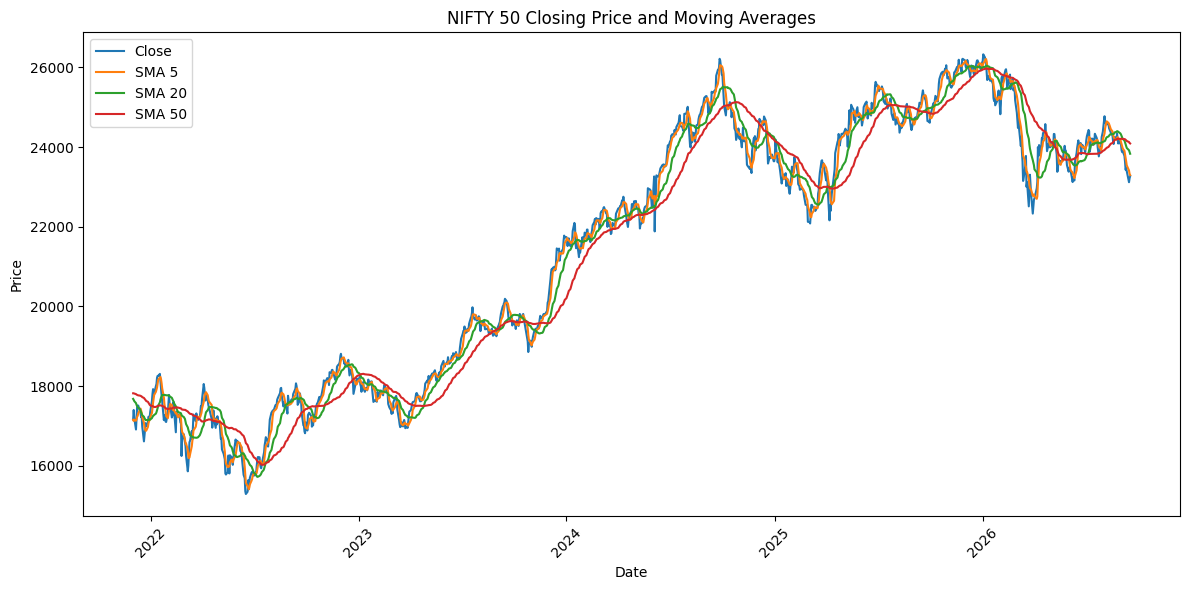

In [13]:
# ------------------------------------------------------------
# 9. Moving averages
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["SMA_5"], label="SMA 5")
plt.plot(df["Date"], df["SMA_20"], label="SMA 20")
plt.plot(df["Date"], df["SMA_50"], label="SMA 50")

plt.title("NIFTY 50 Closing Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

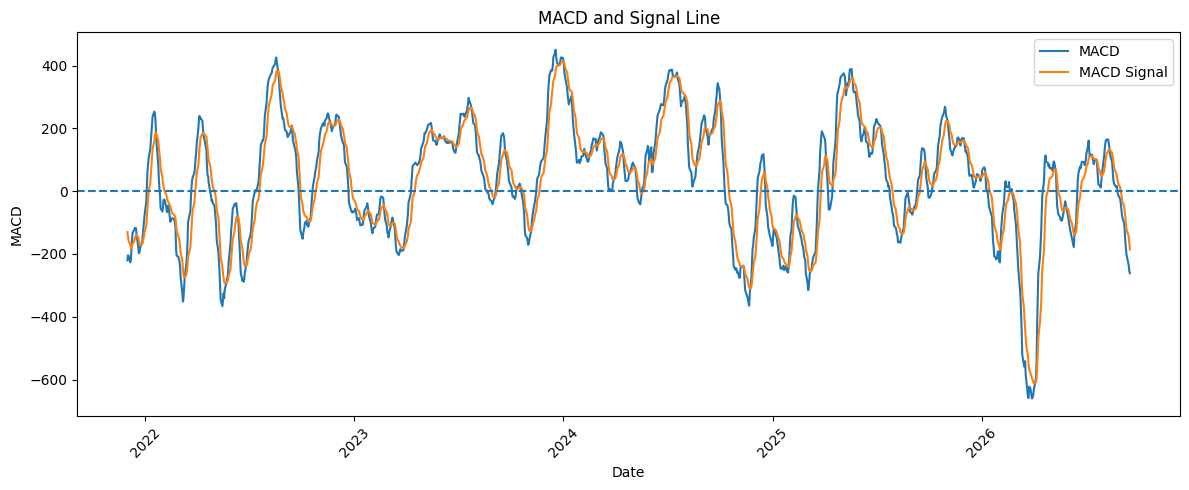

In [14]:
# ------------------------------------------------------------
# 10. MACD analysis
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["MACD"], label="MACD")
plt.plot(df["Date"], df["MACD_Signal"], label="MACD Signal")

plt.axhline(0, linestyle="--")

plt.title("MACD and Signal Line")
plt.xlabel("Date")
plt.ylabel("MACD")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [15]:
# ------------------------------------------------------------
# 11. Correlation matrix
# ------------------------------------------------------------

correlation_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Daily_Return",
    "SMA_5",
    "SMA_10",
    "SMA_20",
    "SMA_50",
    "Momentum_10",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "Volatility_20",
    "Target"
]

corr = df[correlation_columns].corr()

print("\n===== CORRELATION MATRIX =====")
print(corr.round(3))


===== CORRELATION MATRIX =====
                Open   High    Low  Close  Daily_Return  SMA_5  SMA_10  \
Open           1.000  1.000  0.999  0.999        -0.020  0.999   0.996   
High           1.000  1.000  0.999  1.000        -0.007  0.999   0.997   
Low            0.999  0.999  1.000  1.000        -0.001  0.998   0.996   
Close          0.999  1.000  1.000  1.000         0.013  0.998   0.996   
Daily_Return  -0.020 -0.007 -0.001  0.013         1.000 -0.031  -0.036   
SMA_5          0.999  0.999  0.998  0.998        -0.031  1.000   0.999   
SMA_10         0.996  0.997  0.996  0.996        -0.036  0.999   1.000   
SMA_20         0.992  0.992  0.991  0.991        -0.037  0.995   0.998   
SMA_50         0.980  0.981  0.979  0.980        -0.034  0.983   0.987   
Momentum_10    0.052  0.050  0.060  0.060         0.289  0.026  -0.018   
RSI_14         0.012  0.010  0.019  0.019         0.220 -0.007  -0.041   
MACD           0.128  0.124  0.132  0.129         0.041  0.118   0.091   
MACD_S

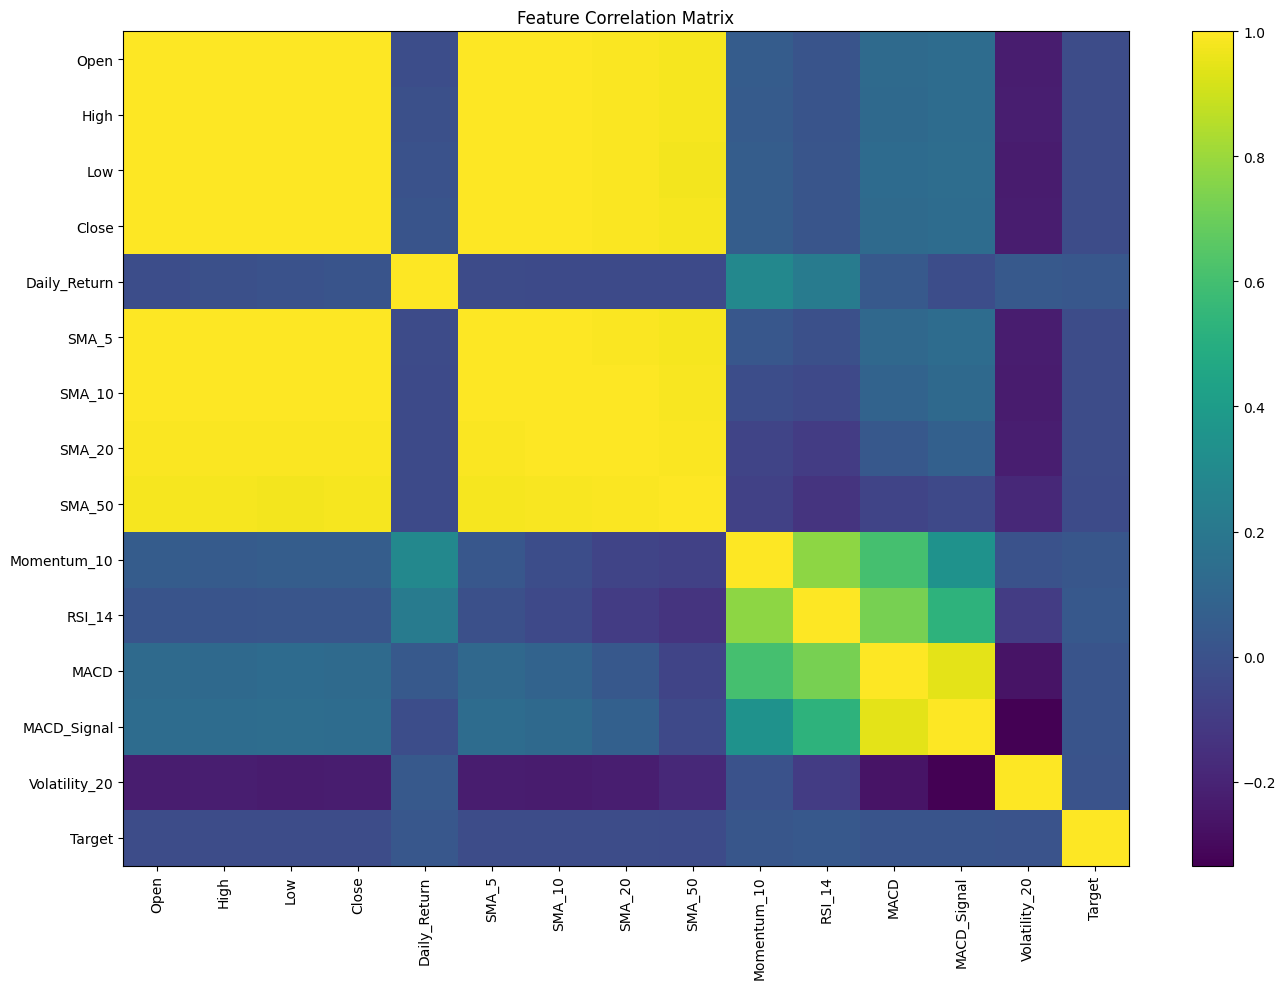

In [16]:
plt.figure(figsize=(14, 10))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [17]:
# ------------------------------------------------------------
# 12. Feature vs Target — Daily Return
# ------------------------------------------------------------

print("\n===== DAILY RETURN BY TARGET =====")

print(
    df.groupby("Target")["Daily_Return"]
    .agg(["mean", "median", "std", "min", "max"])
)


===== DAILY RETURN BY TARGET =====
            mean    median       std       min       max
Target                                                  
0       0.000034 -0.000470  0.008342 -0.026786  0.038183
1       0.000545  0.001284  0.009006 -0.059294  0.033624


<Figure size 700x500 with 0 Axes>

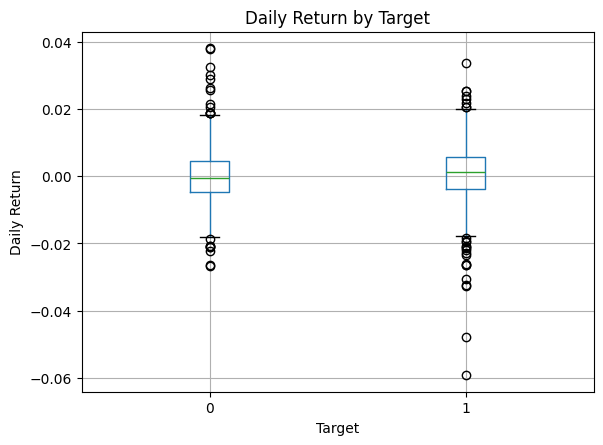

In [18]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="Daily_Return",
    by="Target"
)

plt.title("Daily Return by Target")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("Daily Return")

plt.show()


===== RSI BY TARGET =====
             mean     median        std
Target                                 
0       52.804940  51.945106  17.521701
1       53.893951  53.850589  18.026001


<Figure size 700x500 with 0 Axes>

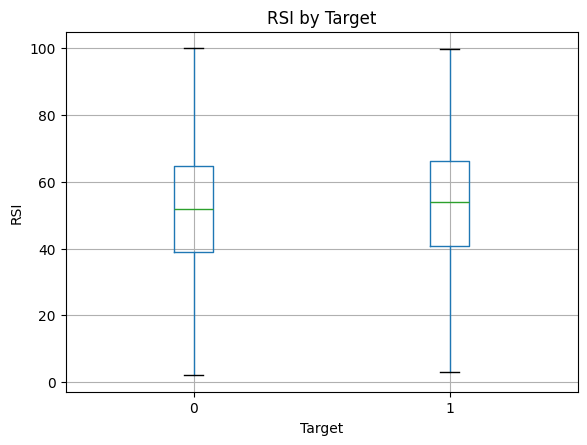

In [19]:
print("\n===== RSI BY TARGET =====")

print(
    df.groupby("Target")["RSI_14"]
    .agg(["mean", "median", "std"])
)

plt.figure(figsize=(7, 5))

df.boxplot(
    column="RSI_14",
    by="Target"
)

plt.title("RSI by Target")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("RSI")

plt.show()


===== MOMENTUM BY TARGET =====
             mean  median         std
Target                               
0       38.815106   19.95  539.328361
1       61.652480  111.10  584.873521


<Figure size 700x500 with 0 Axes>

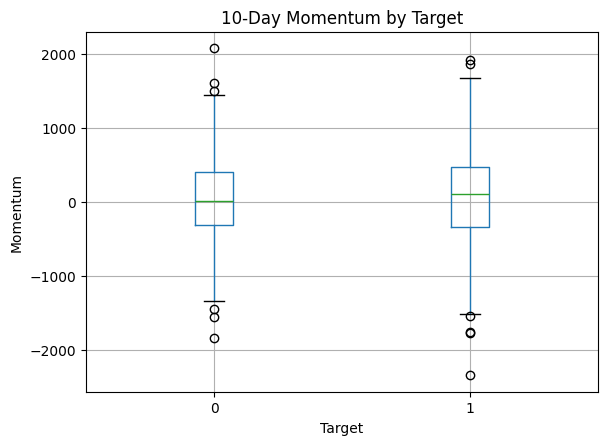

In [20]:
print("\n===== MOMENTUM BY TARGET =====")

print(
    df.groupby("Target")["Momentum_10"]
    .agg(["mean", "median", "std"])
)

plt.figure(figsize=(7, 5))

df.boxplot(
    column="Momentum_10",
    by="Target"
)

plt.title("10-Day Momentum by Target")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("Momentum")

plt.show()


===== VOLATILITY BY TARGET =====
            mean    median       std
Target                              
0       0.008107  0.007304  0.003177
1       0.008151  0.007244  0.003371


<Figure size 700x500 with 0 Axes>

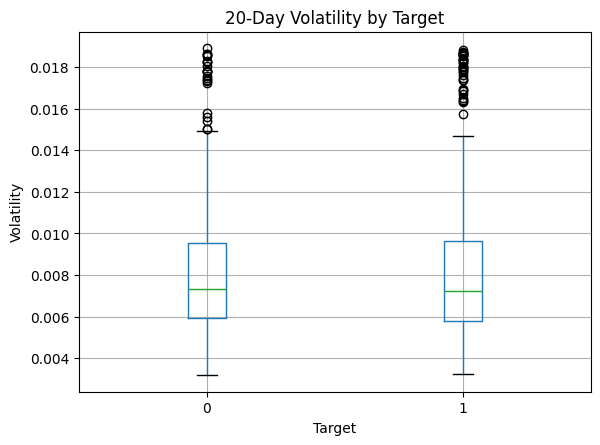

In [21]:
print("\n===== VOLATILITY BY TARGET =====")

print(
    df.groupby("Target")["Volatility_20"]
    .agg(["mean", "median", "std"])
)

plt.figure(figsize=(7, 5))

df.boxplot(
    column="Volatility_20",
    by="Target"
)

plt.title("20-Day Volatility by Target")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("Volatility")

plt.show()

In [22]:
# ------------------------------------------------------------
# 13. FINAL VALIDATION
# ------------------------------------------------------------

print("\n===== FINAL ML-READINESS CHECK =====")

# Missing values
missing_values = df.isnull().sum().sum()

# Infinite values
infinite_values = np.isinf(
    df.select_dtypes(include=np.number)
).sum().sum()

# Target values
unique_targets = sorted(df["Target"].unique())

# Date ordering
is_chronological = df["Date"].is_monotonic_increasing

print("Missing values:", missing_values)
print("Infinite values:", infinite_values)
print("Target values:", unique_targets)
print("Chronological order:", is_chronological)

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

print("\n===== FINAL STATUS =====")

if (
    missing_values == 0
    and infinite_values == 0
    and unique_targets == [0, 1]
    and is_chronological
    and df.duplicated().sum() == 0
):
    print("Dataset is ready for the next ML stage.")
else:
    print("Review the validation results before proceeding.")


===== FINAL ML-READINESS CHECK =====
Missing values: 0
Infinite values: 0
Target values: [np.int64(0), np.int64(1)]
Chronological order: True
Duplicate rows: 0

===== FINAL STATUS =====
Dataset is ready for the next ML stage.
